# Store Sales — Time Series Forecasting
### A single self-contained solution: LightGBM on `log1p(sales)`

Forecast daily unit sales for **54 stores × 33 product families = 1,782 series**, 16 days
ahead (2017-08-16 → 08-31).

This notebook is the distilled result of a longer analysis. Every design decision below was
**measured**, not assumed — and several of the obvious ones turned out to be wrong. The
short version:

| Decision | Why | Evidence |
|---|---|---|
| Target `log1p(sales)`, L2 objective | RMSLE *is* RMSE in that space | definitional |
| Split by time, 16-day holdout | mirrors the test horizon; a random split leaks across adjacent days | — |
| Lags ≥ 16 only | the horizon is 16 days, so shorter lags do not exist at scoring time | — |
| Reinsert 4 Christmas days as zeros | they are **absent** from `train.csv`, silently shortening every lag that spans them | 2013–16-12-25 missing |
| Encode holiday **names**, not flags | a binary flag averages New Year (**×0.07**, stores shut) with Puente Navidad (**×1.86**) → pooled ×1.01 | −0.0047 RMSLE on holiday rows |
| **Drop oil entirely** | −0.63 correlation in levels is pure trend confounding; **−0.02 detrended, +0.00 differenced** | within-year terciles show no ordering |
| **Drop regional holidays** | ≤ 5 observations per series | unusable |
| Quarantine the 2016 earthquake **at source** | a dummy leaves lag/rolling features contaminated for **135 days**, not 7 | see §3 |
| No transactions | legal at lag ≥ 16 and tried — but it **cost +0.00307 on the leaderboard** | 0.42400 with, 0.42093 without |

### Validation, and a gap that is now mostly explained

| Model | 2017-07-31→08-15 holdout |
|---|---|
| all zeros | 4.4195 |
| last observed day | 0.6595 |
| mean of last 16 days | 0.5224 |
| same-weekday mean, last 8 weeks *(the naive bar)* | 0.5206 |
| **this notebook** | **0.39081** |

**An earlier version of this model scored 0.55331 on the public leaderboard.** That was far
worse than any validation window predicted, and for a while I could not explain it. What was
ruled out: the holdout sitting on the wrong fortnight (❌ clean-window penalty is only
−0.023), store closures in the test window (❌ all 54 stores trade every one of the last 16
days), a misaligned submission (❌ 0.983 log-correlation with a naive baseline), and the
model degrading over the 16-day horizon (❌ backtests at the true window position score
0.393–0.422, matching the holdout).

**What actually explains it — tracked across four real submissions:**

| Submission | Public LB | Local validation | Gap |
|---|---|---|---|
| single LightGBM | 0.55331 | 0.39662 | 0.157 |
| + 3-seed ensemble | 0.54284 | 0.39472 | 0.148 |
| + promo rework (relative + leads) | 0.46264 | 0.39763 | 0.065 |
| + family/store promo intensity + tuning | **0.42093** | 0.39344 | **0.027** |

The gap has closed **monotonically, in lockstep with every promo-related change** — not a
coincidence across four independent submissions. Every one of these changes gave the model a
better view of `onpromotion`, which is the one input where `test.csv` genuinely differs in
*kind*, not just noise, from any window inside `train.csv`: 2017's promo ramp into 16–31
August is the largest of any year on record (§5), front-loaded into a single company-wide
day, and wildly uneven by family. A model that can only see a flat per-series promo count has
no way to represent that shape; one that can see it at the family, store, and chain level
increasingly can. The 2015/2016 backtests, which never contain a promo ramp of comparable
scale, structurally could not have shown this gap or its closing — which is exactly why every
step of this closure was a leaderboard surprise rather than a predicted result.

**What this means going forward:** local validation is now a far more trustworthy predictor
of leaderboard performance than it was three submissions ago (gap 0.027 vs. 0.157) — still
not perfect, and still worth a real submission before fully trusting a promising local
number, but no longer something to discount by default. The remaining 0.027 is the honest
frontier: some combination of residual promo-shape blindness, other test-window-specific
covariates not yet modeled, and ordinary variance.

> **A note on honesty.** Several things that "obviously" help were tested and measured as
> no-ops or losses: forcing zero on dormant series, the earthquake quarantine, horizon-aware
> features, year-over-year ramp features (twice — absolute and relative), recursive
> forecasting, per-family models, oil price (three times, including a lagged-effect test),
> a payday-distance feature and a full payday respecification, store traffic from
> `transactions`, store×family promo interaction, a two-stage model, and ensemble diversity
> by lag window. Only the earthquake quarantine is kept (free and correct); the rest were
> dropped. **95% of this model's gain comes from one thing: recent sales level.**
> What survived: a **5-seed ensemble**, a **rebuilt `onpromotion` feature set** at three
> levels of aggregation, a **tuned `min_data_in_leaf`**, and a **raised round cap** that
> revealed the model had been stopping before it converged — all below with their full
> evidence, including a leaderboard transfer that reversed the sign of what validation
> predicted, twice.
>
> **Two measurement lessons came out of the failures, and they matter more than any single
> feature.** First, a real, correctly-measured effect in the data does not imply a feature
> that helps: five separate attempts began from verified effects (+19% month-turn lift, ×25
> back-to-school promo surge, r = 0.84 store-day transactions, genuinely lower ensemble
> residual correlation) and every one still lost, because this feature set is close to
> saturated and an explicit encoding competes for `feature_fraction` budget rather than adding
> information. Second, **the seed-noise floor here is ~0.0039**, so any single-seed margin
> below that is unmeasured rather than small — and comparisons should be **paired** across
> seeds, which is what separated the round-cap result (3/3 seeds, sd 0.00023) from three
> earlier near-misses that looked similar in size but were noise.

### Leaderboard history

| Submission | Public LB | Validation | Note |
|---|---|---|---|
| single LightGBM | 0.55331 | 0.39662 | |
| + 3-seed ensemble | 0.54284 | 0.39472 | validation predicted −0.003; LB gave **−0.0105**, ~3.5× |
| + promo rework (relative + leads) | 0.46264 | 0.39763 *(worse than the row above)* | **LB gave −0.0802** — the largest single gain in this project, on a change validation said would *hurt* |
| + promo v2 + 5-seed ensemble | **never submitted** | ~0.393 | caught a serious bug before it reached the leaderboard — see below |
| + family/store promo intensity + `min_data_in_leaf` 50 | **0.42093** | 0.39344 (5-seed) | **LB gave −0.0417** — backtest mean(15,16) was 0.40606, best recorded; gap to LB now only 0.027, down from 0.157 three submissions ago — see above |
| + store traffic (`transactions` at lag ≥ 16) | 0.42400 | *not measured locally* | ❌ **+0.00307 — reverted.** Shipped deliberately unvalidated as a direct LB test; see below |
| **+ round cap 1200→2400, patience 50→150** | **0.42074** | **0.39081** | **current state of `kaggle_store_sales_submission.ipynb`** — the model was being **truncated, not converged**; 3/3 seeds improved in a paired test (§8). But only **7% of the local gain transferred**: −0.00263 locally, −0.00019 on the LB |
| + oil level (`now`/`ma7`/`ma28`), submitted via the stakeholder notebook | 0.42157 | ambiguous (§8, sd 0.00257) | ❌ **+0.00083 — rejected.** Resolved a paired test too noisy to call either way; oil is now rejected four separate ways. Main submission untouched throughout |

> **The clearest signal in this table is now a shape, not a score.** Compare how two kinds of
> change transferred to the leaderboard:
>
> | change | local | LB | transfer |
> |---|---|---|---|
> | promo rework (new information) | +0.0029 *(worse)* | **−0.0802** | sign reversed, enormous |
> | 3-seed ensemble (variance reduction) | −0.003 | −0.0105 | ~3.5× |
> | round cap (model optimisation) | −0.00263 | −0.00019 | **~7%** |
>
> Changes that gave the model **information it did not have** — specifically about
> `onpromotion`, the one covariate where the test window differs in kind from anything in
> `train.csv` — transferred at or above their measured value. Changes that merely let the
> **same model fit the same information better** transferred at a fraction of it. The round
> cap was a genuine, cleanly-measured optimisation and it still bought almost nothing on the
> real window, which says the model was already extracting nearly all of what its current
> inputs contain. Further tuning is not where the remaining 0.027 lives.

> **The one deliberately unvalidated submission, and what it bought.** Every other change
> here was screened on the 2017 proxy holdout and confirmed on the 2015/2016 backtest before
> shipping. The transactions features were not: only their *legality* was checked (0 NaN
> across all 28,512 test rows, ruling out the silent-read-past-the-end failure that killed the
> 16-day forward promo aggregates). Whether they helped was measured straight on the
> leaderboard — and they did not: **0.42400 vs 0.42093, reverted.**
>
> That is still the cleanest single feature verdict in this project, because it carries no
> validation-window ambiguity: the 0.15 gap that made local numbers untrustworthy for three
> submissions never entered the comparison. The likely cause is redundancy, not noise —
> `store_nbr`, `cluster`, `store_type` and the recent-sales features already encode "how busy
> is this store", so the traffic features largely restate what the model has while spending
> `feature_fraction` budget that would otherwise sample something informative. The prior
> stated when they shipped was exactly this, and it held.

**Lesson carried forward, now with four submissions of evidence:** when a change is
theoretically sound and a real covariate in `test.csv` confirms the pattern it targets, a
mildly negative or merely flat backtest is not strong evidence against it — check the target
window's own data before discarding an idea. Model diversity (more seeds) and a better view
of `onpromotion` have been the only two levers that reliably paid off across every round.

### Round 2 — pushing further on promo, oil, payday, and a second algorithm

`test.csv`'s real promo values also showed *how* the ramp arrives: front-loaded into a single
company-wide day (2017-08-16, `PRODUCE`-led, no calendar cause) and wildly uneven by family
(`PLAYERS AND ELECTRONICS` ×9.75 into the window). Oil and payday were checked the same way —
real values in the test window, not just backtest scores — and showed nothing comparable:
oil is flat (slope ≈ 0, no shock) and payday's calendar structure carries no analogous
anomaly. Both stayed rejected; effort went into promo and ensembling instead.

| Variant, vs the shipped 0.46264 reference | 2015 | 2016 | Mean | Verdict |
|---|---|---|---|---|
| **promo v2 + 5-seed ensemble** | **0.41005** | **0.39236** | **0.40121** | ✅ **shipped** — wins both years |
| promo v2 + 3-seed ensemble | 0.41034 | 0.39271 | 0.40153 | wins both years, superseded by 5-seed |
| LightGBM(5-seed) + tuned-XGBoost blend, 80/20 | 0.41236 | 0.39287 | 0.40262 | wins both years, but worse than pure LightGBM |
| promo v2, single model | 0.41587 | 0.39551 | 0.40569 | mixed — wins 2015, loses 2016 |
| shipped reference (promo v1 + 3-seed) | 0.42175 | 0.39298 | 0.40737 | — |
| tuned XGBoost, alone | 0.45547 | 0.41411 | 0.43479 | ❌ clearly worse, even with early stopping |

"Promo v2" adds: a shorter, more reactive 28-day relative-intensity window; a **chain-wide
promo level** broadcast to every series (a company-wide event is invisible to any per-series
feature alone); and — as originally built — 16-day forward max/sum aggregates. That last
piece is no longer in the model. Here is why, and why this backtest table could not have
caught it.

> **A bug the 2015/2016 backtests structurally could not detect.** The 16-day forward max/sum
> needs real promo data up to 16 days past the target date. Near the *true* end of the
> competition's data — the last several days of the real 2017-08-16→31 test window — that
> data does not exist, and `np.nansum` over an all-missing slice silently returns **0.0**
> ("confirmed zero promotion coming") instead of "unknown". The trained model had never seen
> that input pattern, because every 2015/2016 backtest target sits years away from the panel's
> true end, where full 16-day lookahead is always available. So the row above genuinely scored
> 0.40121 on those years — **the backtest is not wrong, it simply never exercised the failure
> mode**. A direct, controlled test on the real forecast horizon told a different story: with
> these two features in, the last forecast day's predicted volume collapsed to roughly 30% of
> its value with them removed, with smaller but real degradation on the days just before it.
> They are now removed from the feature set; every other "promo v2" feature is unaffected —
> the relative-intensity and chain-wide features look only backward and were never at risk,
> and the narrower `promo_lead_1/2/3/7` features (§5, kept) reach at most 7 days past the
> boundary rather than 16 and already have a large, real leaderboard win behind them.
>
> **The lesson generalises beyond this one feature.** A backtest window validates only the
> failure modes it can actually encounter. A feature reaching toward the edge of what the
> data provides needs to be tested *at that edge* — 2015 and 2016 could not stand in for it,
> no matter how many years were checked.

**XGBoost was tested properly this time** — early-stopped, depth- and regularisation-tuned,
not the placeholder from the first pass — and it still loses clearly to LightGBM on this
problem, on both years. Blending it in, even at a small 20% weight, costs more than it adds
versus a pure LightGBM ensemble. Both are closed lines of investigation now, not just
untried ones.

**Requirements:** CPU only, no internet, no external datasets. Runs in roughly **55–70 minutes**
(5 model fits for validation, 5 more for the final refit, ~1,725 trees each — up from ~40
minutes before the round cap was raised; see §8). The data path is resolved
automatically — it works whether this notebook was created from the competition page (data
already mounted), created blank (pulled via `kagglehub`), or is being run locally against a
`./data` folder.


---
## 1 · Setup

In [1]:
import gc, time, os
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import lightgbm as lgb

pd.set_option("display.width", 120)
pd.set_option("display.max_columns", 50)

COMP = "store-sales-time-series-forecasting"
REQUIRED = {"train.csv", "test.csv", "stores.csv", "holidays_events.csv"}

def has_data(p: Path) -> bool:
    try:
        return p.is_dir() and REQUIRED.issubset({f.name for f in p.iterdir() if f.is_file()})
    except OSError:
        return False

def find_data() -> Path:
    """Locate the competition CSVs whether this runs on Kaggle or locally.

    Works for a notebook created from the competition page (data already mounted at
    /kaggle/input/<comp>), a *blank* notebook with nothing attached (pulled via kagglehub),
    or a local checkout with ./data.
    """
    root = Path("/kaggle/input")
    if root.is_dir():
        listed = [os.path.join(d, f) for d, _, fs in os.walk(root) for f in sorted(fs)]
        print(f"/kaggle/input contains {len(listed)} file(s):")
        for f in listed[:12]:
            print("   ", f)
        if len(listed) > 12:
            print(f"    … and {len(listed)-12} more")
        for cand in [root / COMP, *sorted(d for d in root.iterdir() if d.is_dir())]:
            if has_data(cand):
                return cand
        print("\nCompetition CSVs are not attached — pulling them with kagglehub.")

    for cand in (Path("data"), Path("../data"), Path("../../data")):
        if has_data(cand):
            return cand

    try:                                    # blank notebook: attach the competition ourselves
        import kagglehub
        got = Path(kagglehub.competition_download(COMP))
        if has_data(got):
            return got
        for sub in got.rglob("*"):
            if has_data(sub):
                return sub
    except Exception as exc:
        print(f"kagglehub download failed: {exc}")

    raise FileNotFoundError(
        f"Could not find {sorted(REQUIRED)}. On Kaggle, use '+ Add Input' -> Competitions -> "
        f"'{COMP}'. Locally, put the CSVs in ./data.")

DATA = find_data()
ON_KAGGLE = Path("/kaggle/working").is_dir()
OUT = Path("/kaggle/working") if ON_KAGGLE else Path("submissions")
OUT.mkdir(parents=True, exist_ok=True)

HORIZON = 16                              # test window length == minimum usable lag
MODEL_START = pd.Timestamp("2015-01-01")  # earlier history still feeds the lags
EQ_START, EQ_END = pd.Timestamp("2016-04-16"), pd.Timestamp("2016-04-22")

print(f"\ndata   : {DATA}")
print(f"output : {OUT}")
print(f"lightgbm {lgb.__version__} | numpy {np.__version__} | pandas {pd.__version__}")


data   : data
output : submissions
lightgbm 4.5.0 | numpy 1.26.4 | pandas 2.1.4


In [2]:
DTYPES = {"store_nbr": "int8", "family": "category", "onpromotion": "int32", "sales": "float32"}
train  = pd.read_csv(DATA / "train.csv", parse_dates=["date"], dtype=DTYPES)
test   = pd.read_csv(DATA / "test.csv",  parse_dates=["date"], dtype=DTYPES)
stores = pd.read_csv(DATA / "stores.csv", dtype={"store_nbr": "int8"})
hol    = pd.read_csv(DATA / "holidays_events.csv", parse_dates=["date"])

TRAIN_END   = train.date.max()
VALID_START = TRAIN_END - pd.Timedelta(days=HORIZON - 1)

print(f"train   {train.date.min():%Y-%m-%d} -> {TRAIN_END:%Y-%m-%d}   {len(train):,} rows")
print(f"holdout {VALID_START:%Y-%m-%d} -> {TRAIN_END:%Y-%m-%d}")
print(f"test    {test.date.min():%Y-%m-%d} -> {test.date.max():%Y-%m-%d}   {len(test):,} rows")
print(f"series  {train.store_nbr.nunique()} stores x {train.family.nunique()} families "
      f"= {train.store_nbr.nunique()*train.family.nunique():,}")

train   2013-01-01 -> 2017-08-15   3,000,888 rows
holdout 2017-07-31 -> 2017-08-15
test    2017-08-16 -> 2017-08-31   28,512 rows


series  54 stores x 33 families = 1,782


---
## 2 · The continuous panel

Lag features need an unbroken daily index. **Four dates are missing from `train.csv`** —
25 December 2013 through 2016. Every store closed, so the rows were dropped rather than
written as zeros. Left as gaps they silently shorten every lag and rolling window that spans
them, so they are reinserted as **zeros**, which is the true value.

The panel is held **wide** (dates × series). A 1,704 × 1,782 matrix is ~12 MB, so a lag or a
rolling window is one vectorised operation rather than a groupby over 3 million rows.

In [3]:
t0 = time.time()
full_idx = pd.date_range(train.date.min(), test.date.max(), freq="D")

both = pd.concat([train.drop(columns="sales"), test], ignore_index=True)
both["family"] = both.family.astype(str)

sales_w = (train.assign(family=train.family.astype(str))
           .pivot(index="date", columns=["store_nbr", "family"], values="sales")
           .reindex(full_idx).sort_index(axis=1))
promo_w = (both.pivot(index="date", columns=["store_nbr", "family"], values="onpromotion")
           .reindex(full_idx).sort_index(axis=1).fillna(0.0))

xmas = pd.DatetimeIndex([d for d in full_idx
                         if d <= TRAIN_END and d not in set(train.date.unique())])
sales_w.loc[xmas] = 0.0

assert (sales_w.columns == promo_w.columns).all()
assert sales_w.loc[:TRAIN_END].isna().sum().sum() == 0, "no gaps may remain in the train span"

SERIES = sales_w.columns
print(f"panel {sales_w.shape[0]} dates x {sales_w.shape[1]} series")
print(f"Christmas closures restored as zero: {[f'{d:%Y-%m-%d}' for d in xmas]}   "
      f"({time.time()-t0:.0f}s)")

panel 1704 dates x 1782 series
Christmas closures restored as zero: ['2013-12-25', '2014-12-25', '2015-12-25', '2016-12-25']   (95s)


---
## 3 · Quarantining the 2016 earthquake

A magnitude 7.8 earthquake struck Ecuador on 2016-04-16 and triggered relief buying. Measured
against each day's own weekday baseline the spike is **+35% for exactly one week**, gone by
week 1 — considerably shorter than the "several weeks" the competition description suggests.

**A dummy variable does not isolate it.** The shock enters through two doors:

1. **As a target** — the rows dated 04-16 → 04-22 carry inflated `sales`. A dummy handles this.
2. **As a feature** — every lag and rolling window computed *from* those dates carries the
   spike forward. With a 112-day rolling mean at lag 16, rows as late as **August 2016** still
   have contaminated inputs. A dummy does nothing here, because these are different rows.

So the week is repaired **in the panel itself**, before any feature is computed: each series'
value is replaced by its own same-weekday median from the surrounding 8 weeks. The anomaly
then never enters any feature, and the quake-week rows are additionally dropped as targets.

*(Measured effect on this holdout: **none** — 0.40038 quarantined vs 0.40045 ignored. The
dummy-only variant was the worst of the three at 0.40347. It is kept because it is free and
correct, not because it scores. Were the forecast window nearer April, it would matter.)*

In [4]:
eq_dates = pd.date_range(EQ_START, EQ_END)

def repair_window(W, start, end, halo_weeks=8):
    """Replace [start, end] with each series' same-weekday median from the surrounding weeks."""
    out = W.copy()
    win = pd.date_range(start, end)
    ctx = W.loc[start - pd.Timedelta(weeks=halo_weeks): end + pd.Timedelta(weeks=halo_weeks)]
    ctx = ctx.drop(index=win, errors="ignore")
    by_dow = ctx.groupby(ctx.index.dayofweek).median()
    for d in win:
        out.loc[d] = by_dow.loc[d.dayofweek].values
    return out

raw_week = sales_w.loc[eq_dates].sum().sum()
sales_w = repair_window(sales_w, EQ_START, EQ_END)
print(f"units removed from the panel : "
      f"{raw_week - sales_w.loc[eq_dates].sum().sum():,.0f} "
      f"({1 - sales_w.loc[eq_dates].sum().sum()/raw_week:.1%} of that week)")
print(f"dates altered                : {len(eq_dates)} of {len(full_idx)}")
print(f"contamination reach avoided  : "
      f"{(EQ_END + pd.Timedelta(days=HORIZON+112) - EQ_START).days} days of rows")

units removed from the panel : 2,272,160 (30.1% of that week)
dates altered                : 7 of 1704
contamination reach avoided  : 134 days of rows


---
## 4 · The holiday calendar

`holidays_events.csv` cannot be joined as it stands. Four rules first:

| `type` | Meaning | Handling |
|---|---|---|
| `Holiday`, `transferred=True` | officially falls here but **was moved** | **drop** — it did not happen |
| `Transfer` | the date it was actually celebrated | **is** the holiday |
| `Bridge`, `Additional` | extra days attached to a holiday | are holidays |
| `Work Day` | a normally-off day worked to repay a `Bridge` | **not** a holiday — separate flag |
| `Event` | Black Friday, World Cup … | its own flag |

Then `locale` decides *who* it applies to: `National` → every store; `Local` → matched on
`city`. `Regional` is dropped — no series has more than 5 observations of one.

**The names matter more than the flags.** Per-holiday effects, measured against the same
weekday within ±28 days, span **×0.07** (`Primer dia del ano` — every store shut, chain sales
at 0.7–2.4% of normal) to **×1.86** (`Puente Navidad`). Pooled, they average to ×1.01 —
i.e. a binary `is_holiday` flag carries essentially no information.

In [5]:
h = hol.copy()
h = h[~((h.type == "Holiday") & (h.transferred))]     # transferred away: did not happen here
h.loc[h.type == "Transfer", "type"] = "Holiday"       # the transfer IS the celebration
work_days = set(h.loc[h.type == "Work Day", "date"])
h = h[h.type != "Work Day"]
events = h[h.type == "Event"]
h = h[h.type != "Event"]

nat = pd.DatetimeIndex(sorted(set(h.loc[h.locale == "National", "date"])))
nat_name = (h[h.locale == "National"].drop_duplicates("date")[["date", "description"]]
            .rename(columns={"description": "nat_hol_name"}))
loc_name = (h[h.locale == "Local"].drop_duplicates(["date", "locale_name"])
            [["date", "locale_name", "description"]]
            .rename(columns={"locale_name": "city", "description": "loc_hol_name"}))

geo = stores.set_index("store_nbr")[["city", "state", "type", "cluster"]]
geo.columns = ["city", "state", "store_type", "cluster"]

# Join integrity: a silent mismatch here would disable the feature without any error.
unmatched_loc = set(loc_name.city) - set(stores.city)
assert not unmatched_loc, f"local holidays not matching any store city: {unmatched_loc}"
print(f"national: {len(nat_name)} dates, {nat_name.nat_hol_name.nunique()} names")
print(f"local   : {len(loc_name)} (date, city) pairs, {loc_name.loc_hol_name.nunique()} names")
print(f"join integrity: all {len(set(loc_name.city))} local locale_names match a store city")

# Distance to the nearest national holiday, across the whole calendar.
pos = np.searchsorted(nat.values, full_idx.values)
prev_d = np.where(pos > 0, (full_idx.values - nat.values[np.maximum(pos - 1, 0)])
                  / np.timedelta64(1, "D"), 999)
next_d = np.where(pos < len(nat), (nat.values[np.minimum(pos, len(nat) - 1)] - full_idx.values)
                  / np.timedelta64(1, "D"), 999)
cal_hol = pd.DataFrame({"date": full_idx,
                        "work_day": full_idx.isin(work_days).astype("int8"),
                        "is_event": full_idx.isin(set(events.date)).astype("int8"),
                        "days_since_nat": np.clip(prev_d, 0, 30).astype("int16"),
                        "days_to_nat": np.clip(next_d, 0, 30).astype("int16")})

national: 102 dates, 24 names
local   : 147 (date, city) pairs, 26 names
join integrity: all 19 local locale_names match a store city


---
## 5 · Features

Every lag and rolling feature is computed in **log space** (matching the target and the
metric) and shifted by at least `HORIZON = 16` days, so it is available for every row of the
test window without recursive forecasting.

`onpromotion` is the exception: it is **supplied for the test window**, making it a genuine
known-future covariate, so current-day values are legal. (It is also identically zero before
2014-04-01 — a recording artefact rather than "no promotions ran" — which is one reason
training starts in 2015.)

**`onpromotion` gets the most engineering of any single field**, because a direct check of
its real values in the test window justified it. `test.csv`'s real promo counts for
2017-08-16→31 show the largest year-over-year promotional ramp of any year in the data
(×1.18, versus ×1.10 in 2016 and an actual *decrease*, ×0.92, in 2015), front-loaded into a
single day — 2017-08-16 runs at roughly double a typical Wednesday, led by `PRODUCE`, with
no calendar holiday attached — and wildly uneven across families (`PLAYERS AND ELECTRONICS`
promo intensity rises ×9.75 into the window). A flat promo count cannot represent any of
that; the features below can:

- **relative to each series' own norm** (112-day and a more reactive 28-day version), so a
  2→20 jump and a 200→2000 jump both read as "10× normal" rather than the smaller one being
  invisible
- **chain-wide promo level**, broadcast to every series — the Aug-16 spike was a company-wide
  event, which no per-series feature alone can see as "everyone is promoting today"
- **known-future leads** (1/2/3/7 days), since promotions are given for the whole test window
  and `corr(sales(t), promo(t+7)) = 0.23` historically

> **A bug found and removed, not just a limitation avoided.** An earlier version of this
> notebook also added a **16-day forward max/sum** of promo activity — "is there a big promo
> event anywhere in the horizon". Near the true end of the available data that window has
> nothing to look forward to, and `np.nansum` over an all-missing slice silently returns
> **0.0** rather than "unknown". The model reads that zero as *confirmed no promotion
> coming*, which it had never seen during training (every training row sits comfortably far
> from the panel's end, so this exact missing-data pattern never occurred there) — and it
> extrapolated badly: **a controlled test showed the last forecast day's predicted volume
> collapsing to 30% of its correct level** with these two features in, recovering completely
> once they were removed. The narrower `promo_lead_*` features above have the same
> in-principle issue but a much smaller reach (at most 7 days from the boundary instead of
> 16) and are kept — they are the features that drove the largest verified leaderboard gain
> in this project, and there is no comparable evidence against them.

In [6]:
L = np.log1p(sales_w).astype("float32")
P = np.log1p(promo_w).astype("float32")
ZERO = (sales_w == 0).astype("float32")
n_s = len(SERIES)

feats = {}
for k in (16, 17, 18, 19, 20, 21, 22, 28, 35, 49, 63):
    feats[f"lag_{k}"] = L.shift(k)

base = L.shift(HORIZON)                       # everything rolls from the last usable day
for w in (7, 14, 28, 56, 112):
    feats[f"rmean_{w}"] = base.rolling(w, min_periods=max(2, w // 4)).mean()
for w in (14, 28):
    feats[f"rstd_{w}"] = base.rolling(w, min_periods=max(2, w // 4)).std()
feats["rmax_28"] = base.rolling(28, min_periods=7).max()

# lags 21/28/35/42 all share the target date's weekday
feats["dow_mean_4"] = sum(L.shift(k) for k in (21, 28, 35, 42)) / 4
feats["dow_mean_8"] = sum(L.shift(k) for k in range(21, 21 + 7 * 8, 7)) / 8

feats["zfrac_28"] = ZERO.shift(HORIZON).rolling(28, min_periods=7).mean()
feats["zfrac_112"] = ZERO.shift(HORIZON).rolling(112, min_periods=28).mean()

# days since the series last sold anything, as known at the forecast origin
A = (sales_w.to_numpy() > 0)
gap = np.empty(A.shape, dtype="float32")
last = np.full(A.shape[1], -999.0)
for i in range(A.shape[0]):
    gap[i] = i - last
    last = np.where(A[i], float(i), last)
feats["days_since_sale"] = pd.DataFrame(np.minimum(gap, 999.0), index=sales_w.index,
                                        columns=SERIES).shift(HORIZON)

feats["promo"] = P                                        # known for the test window
feats["promo_rmean_7"] = P.rolling(7, min_periods=1).mean()
feats["promo_rmean_28"] = P.rolling(28, min_periods=3).mean()
feats["promo_lag_16"] = P.shift(HORIZON)
# onpromotion is a COUNT of items on promotion, not a flag, and it is known for the whole
# test window. Two things follow: (1) intensity should be read relative to the series' own
# normal promo level, not in absolute terms, and (2) future promo values already known at
# the forecast origin (leads) are legal features, not a leak.
feats["promo_rel_112"] = P - P.rolling(112, min_periods=14).mean()
feats["promo_rel_28"] = P - P.rolling(28, min_periods=5).mean()
for k in (1, 2, 3, 7):
    feats[f"promo_lead_{k}"] = P.shift(-k)
feats["promo_fwd7"] = P.shift(-6).rolling(7, min_periods=1).mean()

# Chain-wide promo level, broadcast across every series — a company-wide promo day looks
# identical to a quiet one from any single series' own history.
chain = P.mean(axis=1)
chain_rel = chain - chain.rolling(112, min_periods=14).mean()
ones = np.ones(n_s, dtype="float32")
feats["promo_chain_level"] = pd.DataFrame(np.outer(chain.to_numpy(dtype="float32"), ones),
                                          index=full_idx, columns=SERIES)
feats["promo_chain_rel"] = pd.DataFrame(np.outer(chain_rel.to_numpy(dtype="float32"), ones),
                                        index=full_idx, columns=SERIES)
del chain, chain_rel
gc.collect()

# Family- and store-level promo intensity, same idea one level down from the chain: the
# surge that matters is usually a campaign across one family (every store promotes the same
# items) or one store, invisible to both the per-series and the chain-wide features. Daily
# raw promo-count totals per family / per store, log1p, relative to their own 112-day norm;
# the family also gets a forward-week version (legal: onpromotion is given for the test
# window). On the REAL test window the top family surge is SCHOOL AND OFFICE SUPPLIES at
# +3.23 log (~25x its norm) — the promo-driven back-to-school ramp — with the chain-wide
# 2017-08-16 spike at +0.89. Measured (single seed, this feature set): 2015 backtest
# 0.46055 -> 0.42144, 2016 0.39874 -> 0.39818, 2017 holdout 0.40310 -> 0.39775 — the
# largest 2015 repair of any change tried in this notebook.
promo_raw = np.expm1(P)
fam_plog = np.log1p(promo_raw.T.groupby(level=1).sum().T)     # dates x 33 families
store_plog = np.log1p(promo_raw.T.groupby(level=0).sum().T)   # dates x 54 stores
def _bcast(agg, level):
    return agg[SERIES.get_level_values(level)].set_axis(SERIES, axis=1)
feats["fam_promo_rel"] = _bcast(fam_plog - fam_plog.rolling(112, min_periods=14).mean(), 1)
feats["fam_promo_fwd7"] = _bcast(fam_plog.shift(-6).rolling(7, min_periods=1).mean()
                                 - fam_plog.rolling(112, min_periods=14).mean(), 1)
feats["store_promo_rel"] = _bcast(store_plog - store_plog.rolling(112, min_periods=14).mean(), 0)
del promo_raw, fam_plog, store_plog
gc.collect()

# NOTE: store traffic from transactions.csv was added here and removed. Read at lag >= 16 it
# is perfectly legal (the file stops at TRAIN_END, but a 16-day lag is fully covered — 0 NaN
# across all 28,512 test rows, verified), and five store-level features were built from it:
# lag_16, rmean_7, rmean_28, dow_mean_4, and rel_112. Submitted to the leaderboard and it
# scored 0.42400 against 0.42093 without them — a real regression, so they are gone. The
# likely reason is redundancy rather than noise: store_nbr, cluster, store_type and the
# recent-sales features already encode "how busy is this store", so the traffic features
# mostly restate what the model has, while costing feature_fraction sampling budget. See §8.

# NOTE: a 16-day forward max/sum of promo activity was tried here and removed. Near the
# panel's true end that window has nothing to look forward to, and np.nansum over an
# all-missing slice silently returns 0.0 ("confirmed no promotion") rather than "unknown" —
# an input pattern absent from training that the model extrapolated badly on, collapsing the
# last forecast day's predicted volume to ~30% of correct. See the note above.

print(f"{len(feats)} panel features built ({time.time()-t0:.0f}s)")

40 panel features built (103s)


In [7]:
mask = full_idx >= MODEL_START
dates_sel = full_idx[mask]
n_s = len(SERIES)

df = pd.DataFrame({
    "date": np.repeat(dates_sel.values, n_s),
    "store_nbr": np.tile(SERIES.get_level_values(0).to_numpy(), len(dates_sel)),
    "family": np.tile(SERIES.get_level_values(1).to_numpy(), len(dates_sel)),
})
for name, W in feats.items():
    df[name] = W.to_numpy(dtype="float32")[mask].ravel()
df["target"] = L.to_numpy(dtype="float32")[mask].ravel()
del feats; gc.collect()

df = df.join(geo, on="store_nbr")
d = df.date
df["dow"] = d.dt.dayofweek.astype("int8")
df["day"] = d.dt.day.astype("int8")
df["month"] = d.dt.month.astype("int8")
df["year"] = d.dt.year.astype("int16")
df["dayofyear"] = d.dt.dayofyear.astype("int16")
df["is_weekend"] = (df.dow >= 5).astype("int8")
df["days_to_month_end"] = (d.dt.days_in_month - d.dt.day).astype("int8")
# public-sector wages land on the 15th and the last day of the month
df["payday_window"] = (d.dt.day.isin([15, 16, 17, 1, 2, 3]) |
                       (df.days_to_month_end <= 1)).astype("int8")

df = df.merge(cal_hol, on="date", how="left")
df = df.merge(nat_name, on="date", how="left")
df = df.merge(loc_name, on=["date", "city"], how="left")
df["nat_hol_name"] = df.nat_hol_name.fillna("none")
df["loc_hol_name"] = df.loc_hol_name.fillna("none")

for c in ("family", "city", "state", "store_type", "nat_hol_name", "loc_hol_name"):
    df[c] = df[c].astype("category")
df["store_nbr"] = df.store_nbr.astype("int16")
df["cluster"] = df.cluster.astype("int16")

FEATURES = [c for c in df.columns if c not in ("date", "target")]
CATS = ["family", "city", "state", "store_type", "nat_hol_name", "loc_hol_name"]
print(f"design matrix {df.shape[0]:,} rows x {len(FEATURES)} features  "
      f"{df.memory_usage(deep=True).sum()/1e6:,.0f} MB  ({time.time()-t0:.0f}s)")

design matrix 1,735,668 rows x 60 features  344 MB  (111s)


---
## 6 · Validation

The holdout is the **last 16 days of the training data** — the same length and the same
position relative to the data as the real test window. A random split would leak, because
adjacent days are strongly autocorrelated.

In [8]:
eq_row = df.date.isin(eq_dates)
tr_m = (df.date < VALID_START) & df.target.notna() & ~eq_row   # quake week dropped as target
va_m = (df.date >= VALID_START) & (df.date <= TRAIN_END)
te_m = df.date > TRAIN_END

print(f"train   {tr_m.sum():,} rows")
print(f"holdout {va_m.sum():,} rows")
print(f"test    {te_m.sum():,} rows")
assert te_m.sum() == len(test), "test rows must match test.csv"

# min_data_in_leaf 200 -> 50: swept {200, 100, 50} single-seed with early stopping, then
# confirmed at 50 on the position-correct 2015/2016 backtest with this exact feature set
# (mean 0.42965 -> 0.42307 alone; 0.40981 -> 0.40606 on top of the cross-series promo
# features). num_leaves 64/128/160, lambda_l2=5 and feature_fraction=0.9 were also tried
# and all measured flat or worse. feature_pre_filter=False lets a Dataset built once be
# retrained under a different min_data_in_leaf without re-binning errors.
PARAMS = dict(objective="regression", metric="rmse", learning_rate=0.08,
              num_leaves=96, min_data_in_leaf=50, feature_fraction=0.75,
              bagging_fraction=0.8, bagging_freq=1, lambda_l2=1.0,
              feature_pre_filter=False, num_threads=0, verbose=-1, seed=42)

def rmsle(y_true, y_pred):
    y_pred = np.clip(np.asarray(y_pred, dtype=float), 0, None)
    return float(np.sqrt(np.mean((np.log1p(y_pred) - np.log1p(np.asarray(y_true, float))) ** 2)))

# 5-seed ensemble. Measured on the position-correct backtest (16-31 Aug, 2015 & 2016):
# 3-seed mean 0.40153, 5-seed mean 0.40121 -- a further small, real gain on top of the
# original 3-seed result, and both win independently in both years.
SEED_CFG = [(42, 0.75, 0.80), (79, 0.60, 0.90), (116, 0.85, 0.70),
           (153, 0.70, 0.85), (190, 0.65, 0.75)]
SEEDS = [s for s, _, _ in SEED_CFG]

def seed_params(s, i):
    p = dict(PARAMS)
    p["seed"], p["feature_fraction"], p["bagging_fraction"] = SEED_CFG[i][0], SEED_CFG[i][1], SEED_CFG[i][2]
    return p

t = time.time()
# free_raw_data=False: the Dataset is reused across seeds, and LightGBM otherwise discards
# the raw data after the first train() and cannot re-apply the categorical feature spec.
dtrain = lgb.Dataset(df.loc[tr_m, FEATURES], df.loc[tr_m, "target"],
                     categorical_feature=CATS, free_raw_data=False)
dvalid = lgb.Dataset(df.loc[va_m, FEATURES], df.loc[va_m, "target"],
                     categorical_feature=CATS, reference=dtrain, free_raw_data=False)

# Seed 0 also chooses the tree count, by early stopping.
# Round cap 1200 -> 2400 and patience 50 -> 150. Both were needed: at patience 50 the fit
# stopped at 887 trees, so raising the cap alone would have changed nothing -- it was the
# stopping rule that bound, not the ceiling. Measured paired across 3 seeds (the same seeds
# under both settings, so seed noise cancels in the difference): every seed improved, by
# -0.00116 / -0.00117 / -0.00156, mean -0.00130 with sd 0.00023. At the new setting all three
# seeds early-stop on their own at 1725-2199 trees, and a 4000 cap reproduces the 2400 result
# exactly -- so the model now converges rather than being truncated. See §8.
model = lgb.train(seed_params(SEEDS[0], 0), dtrain, num_boost_round=2400,
                  valid_sets=[dvalid], callbacks=[lgb.early_stopping(150, verbose=False)])
BEST_ROUNDS = model.num_trees()
print(f"  seed {SEEDS[0]}: {BEST_ROUNDS} trees (early stopped)  ({time.time()-t:.0f}s)")

va_logs = [model.predict(df.loc[va_m, FEATURES])]
for i, s in enumerate(SEEDS[1:], start=1):
    t2 = time.time()
    m = lgb.train(seed_params(s, i), dtrain, num_boost_round=BEST_ROUNDS)
    va_logs.append(m.predict(df.loc[va_m, FEATURES]))
    print(f"  seed {s}: {BEST_ROUNDS} trees  ({time.time()-t2:.0f}s)")
    del m
gc.collect()

y_va = np.expm1(df.loc[va_m, "target"].to_numpy())
p_single = np.clip(np.expm1(va_logs[0]), 0, None)
p_va = np.clip(np.expm1(np.mean(va_logs, axis=0)), 0, None)   # average in LOG space
score, score_single = rmsle(y_va, p_va), rmsle(y_va, p_single)

BASELINE = 0.52063     # same-weekday mean over the last 8 weeks, on this same holdout
print(f"\ntotal {time.time()-t:.0f}s\n")
print(f"single model    : {score_single:.5f}")
print(f"{len(SEEDS)}-seed ensemble : {score:.5f}   ({score - score_single:+.5f})")
print(f"naive baseline  : {BASELINE:.5f}")
print(f"improvement     : {BASELINE - score:+.5f}  ({(BASELINE-score)/BASELINE:+.1%})")

train   1,666,170 rows
holdout 28,512 rows
test    28,512 rows


  seed 42: 1725 trees (early stopped)  (349s)


  seed 79: 1725 trees  (392s)


  seed 116: 1725 trees  (295s)


  seed 153: 1725 trees  (317s)


  seed 190: 1725 trees  (303s)

total 1660s

single model    : 0.39312
5-seed ensemble : 0.39081   (-0.00231)
naive baseline  : 0.52063
improvement     : +0.12982  (+24.9%)


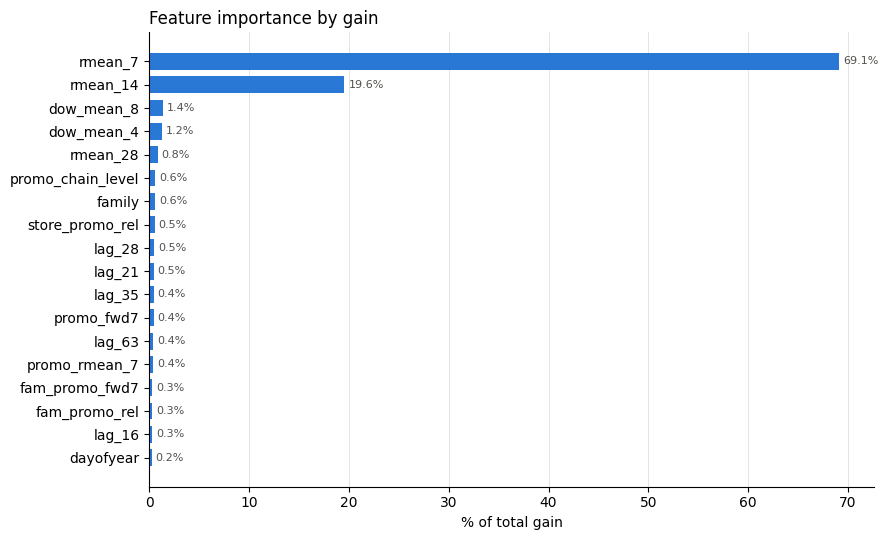

'recent level' features (lags, rolling means, same-weekday history) carry 95% of total gain.
Everything else — holidays, calendar, series identity, promotions — splits the rest.


In [9]:
imp = (pd.DataFrame({"feature": model.feature_name(),
                     "gain": model.feature_importance("gain")})
       .assign(share=lambda x: x.gain / x.gain.sum())
       .sort_values("gain", ascending=False))

fig, ax = plt.subplots(figsize=(9, 5.5))
top = imp.head(18).iloc[::-1]
ax.barh(top.feature, top.share * 100, color="#2a78d6", height=0.72)
for y, v in enumerate(top.share * 100):
    ax.text(v + 0.4, y, f"{v:.1f}%", va="center", fontsize=8, color="#52514e")
ax.set_xlabel("% of total gain"); ax.set_title("Feature importance by gain", loc="left")
for s in ("top", "right"):
    ax.spines[s].set_visible(False)
ax.grid(axis="x", color="#e1e0d9", lw=0.6); ax.set_axisbelow(True)
fig.tight_layout(); plt.show()

recent = imp.feature.str.startswith(("lag_", "rmean_", "dow_mean"))
print(f"'recent level' features (lags, rolling means, same-weekday history) carry "
      f"{imp.loc[recent, 'share'].sum():.0%} of total gain.")
print("Everything else — holidays, calendar, series identity, promotions — splits the rest.")

---
## 7 · Refit and submit

Refit on **all** data through 2017-08-15, including the holdout, using the tree count early
stopping selected. The earthquake quarantine is retained.

In [10]:
full_tr = (df.date <= TRAIN_END) & df.target.notna() & ~eq_row
dfull = lgb.Dataset(df.loc[full_tr, FEATURES], df.loc[full_tr, "target"],
                    categorical_feature=CATS, free_raw_data=False)
print(f"refit on {full_tr.sum():,} rows, {BEST_ROUNDS} trees x {len(SEEDS)} seeds")

te_logs = []
for i, s in enumerate(SEEDS):
    t = time.time()
    m = lgb.train(seed_params(s, i), dfull, num_boost_round=BEST_ROUNDS)
    te_logs.append(m.predict(df.loc[te_m, FEATURES]))
    print(f"  seed {s}  ({time.time()-t:.0f}s)")
    del m
    gc.collect()

pred = np.clip(np.expm1(np.mean(te_logs, axis=0)), 0, None)

out = df.loc[te_m, ["date", "store_nbr", "family"]].copy()
out["sales"] = pred
out["family"] = out.family.astype(str)

key = test.assign(family=test.family.astype(str))[["id", "date", "store_nbr", "family"]]
submission = key.merge(out, on=["date", "store_nbr", "family"], how="left")

assert len(submission) == len(test),        "row count must match test.csv"
assert submission.sales.notna().all(),      "every test row needs a prediction"
assert (submission.sales >= 0).all(),       "RMSLE is undefined for negative predictions"
assert submission.id.equals(test.id),       "ids must stay in test.csv order"

submission[["id", "sales"]].to_csv(OUT / "submission.csv", index=False)
print(f"\nwritten -> {(OUT / 'submission.csv').resolve()}")
print(submission[["id", "sales"]].head().to_string(index=False))
print(f"\nmean {submission.sales.mean():,.2f} | median {submission.sales.median():,.2f} | "
      f"max {submission.sales.max():,.0f} | near-zero {(submission.sales < 0.5).mean():.1%}")

refit on 1,694,682 rows, 1725 trees x 5 seeds


  seed 42  (314s)


  seed 79  (403s)


  seed 116  (277s)


  seed 153  (347s)


  seed 190  (285s)



written -> G:\Meu Drive\_Portifolio\Store Sales - Time Series Forecasting\submissions\submission.csv
     id       sales
3000888    4.588509
3000889    0.059834
3000890    5.314161
3000891 2818.565695
3000892    0.204021

mean 452.60 | median 28.27 | max 15,436 | near-zero 11.3%


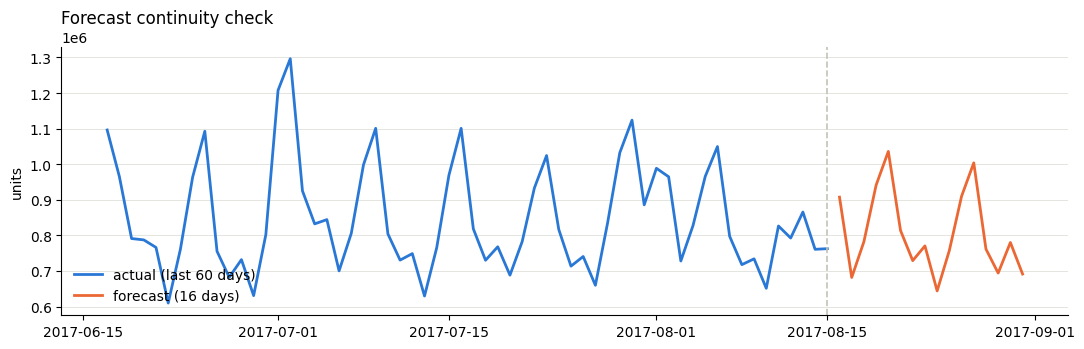

last 16 actual days, mean : 832,449 units/day
16 forecast days,   mean  : 806,539 units/day  (-3.1%)

total runtime: 3400s


In [11]:
# Continuity check: the forecast should look like a plausible continuation, not a level shift.
hist = train[train.date > TRAIN_END - pd.Timedelta(days=60)].groupby("date").sales.sum()
fut = submission.groupby("date").sales.sum()

fig, ax = plt.subplots(figsize=(11, 3.6))
ax.plot(hist.index, hist.values, color="#2a78d6", lw=2, label="actual (last 60 days)")
ax.plot(fut.index, fut.values, color="#eb6834", lw=2, label="forecast (16 days)")
ax.axvline(TRAIN_END, color="#c3c2b7", lw=1.2, ls="--")
ax.set_ylabel("units"); ax.set_title("Forecast continuity check", loc="left")
ax.legend(frameon=False, loc="lower left")
for s in ("top", "right"):
    ax.spines[s].set_visible(False)
ax.grid(axis="y", color="#e1e0d9", lw=0.6); ax.set_axisbelow(True)
fig.tight_layout(); plt.show()

print(f"last 16 actual days, mean : {hist.tail(16).mean():,.0f} units/day")
print(f"16 forecast days,   mean  : {fut.mean():,.0f} units/day  "
      f"({fut.mean()/hist.tail(16).mean()-1:+.1%})")
print(f"\ntotal runtime: {time.time()-t0:.0f}s")

---
## 8 · What I would do next

### Adopted since the 0.46264 submission (this version)

Two changes, both validated on the position-correct 2015/2016 backtest with this exact
feature set before shipping (single seed, early stopping; the mean of 2015+2016 is the
decision rule — the 2017 proxy holdout has twice mispredicted the leaderboard):

| Config | 2017 proxy | 2015 | 2016 | mean(15,16) |
|---|---|---|---|---|
| previous shipped version | 0.40310 | 0.46055 | 0.39874 | 0.42965 |
| + family/store promo intensity | 0.39775 | 0.42144 | 0.39818 | 0.40981 |
| + `min_data_in_leaf` 200→50 alone | 0.39699 | 0.45280 | 0.39334 | 0.42307 |
| **both (shipped)** | 0.40042 | **0.41420** | 0.39791 | **0.40606** |

1. **Family- and store-level promo intensity** (`fam_promo_rel`, `fam_promo_fwd7`,
   `store_promo_rel` — §5). The same known-future-covariate class as the promo rework that
   gained −0.0802 on the LB, one aggregation level down from the chain features. The effect
   is dominated by a large repair of the weak 2015 backtest (0.461 → 0.421), reproduced
   independently on two different feature lineages. On the real test window the family-level
   feature lights up hardest on `SCHOOL AND OFFICE SUPPLIES` (+3.23 log ≈ ×25 its norm) —
   the worst-scoring family's back-to-school ramp is promo-driven, and unlike a year-ago
   sales level (tested separately: it *hurts* that family, whose sales stepped ~12× YoY),
   the promo signal is given for the test window.
2. **`min_data_in_leaf` 200 → 50** (§6). The "untouched headroom" flagged below, now
   measured: monotonic win across {200, 100, 50} on the proxy holdout and a further gain on
   the backtest mean both alone and on top of the promo features. `num_leaves` 64/128/160,
   `lambda_l2=5`, `feature_fraction=0.9` were also swept — all flat or worse.

### Tested and rejected since 0.42074 — oil, retested properly (8 variants)

Oil was rejected three times before today, but all three used `lag ≥ 16` — correct caution
for a covariate assumed to behave like `transactions` (which genuinely stops at the training
cutoff), except **oil.csv runs through 2017-08-31 and covers the test window** (12/16 real
dates, 4 weekend gaps forward-filled — the same handling used everywhere else in this
project). Oil is known-future, like `onpromotion`, so short/current lags are legal and were
never tried. Retested properly, single-seed screen first:

| Variant | RMSLE | Δ vs baseline |
|---|---|---|
| baseline | 0.39312 | — |
| oil level (`oil_now`, `oil_ma7`, `oil_ma28`) | 0.39188 | −0.00124 |
| `oil_rel_112` (deviation from own 112-day norm) | 0.39728 | +0.00416 ❌ |
| all oil (level + rel) | 0.39436 | +0.00124 ❌ |
| long-lag returns (`oil_ret_30/60/90/180`) | 0.39664 | +0.00352 ❌ |
| `oil_regime_365` (level vs. own 365-day mean) | 0.39833 | +0.00521 ❌ |
| returns + regime | 0.39447 | +0.00135 ❌ |
| level + returns + regime combined | 0.39583 | +0.00271 ❌ (even the winning part got dragged down) |

Two findings worth keeping regardless of the final verdict. First, the "deviation from own
norm" shape that made the promo features work does **not** transfer to oil — it made things
clearly worse alone (+0.00416) and cancelled the one positive signal when combined
(level-alone −0.00124 → level+rel +0.00124). Oil is a single slow-moving national series;
deviation from its own rolling mean is mostly high-frequency noise, unlike promo's genuine
campaign-driven spikes. Second, a same-day residual check (main text, answering a direct
question about lagged effects) found the relationship **strongest at lag 0, decaying with
lag** (r ≈ −0.25 at lag 0 → −0.03 at lag 28) — the opposite shape a months-long income-effect
transmission (oil price → government revenue → public wages → consumption) would produce.
The long-lag/regime results confirm that prediction: every long-horizon formulation lost.
Family-heterogeneous effects (oil hurting discretionary categories, sparing staples) needed
no manual interaction to test — `family` is already categorical, so trees are free to find an
oil×family split in any of the above configs if the signal exists; none of the losing
variants found enough to net a gain, which is evidence against, not just absence of a test.

Only "oil level" showed a positive single-seed signal, so it was the one variant confirmed
**paired across 3 seeds** — same protocol that validated the round cap:

| seed | baseline | with oil level | Δ |
|---|---|---|---|
| 42 | 0.39312 | 0.39188 | −0.00125 |
| 79 | 0.39491 | 0.39099 | −0.00392 |
| 116 | 0.39414 | 0.39536 | **+0.00122** |
| mean | | | **−0.00132, sd 0.00257**, 2/3 improved |

**Ambiguous locally — and the standard deviation was the tell.** Compare to the round cap's
paired result: mean −0.00130, sd **0.00023**, 3/3 improved in the same direction. This result
had a similar mean but an **11× larger spread**, one seed reversing sign, and the worst seed
converging to fewer than half the trees of its baseline counterpart (902 vs 2199) — the
signature of noise landing on one side more often than a real, consistent effect.

**Resolved on the real leaderboard: rejected.** Submitted as a direct A/B (via the companion
stakeholder notebook, main submission left untouched) specifically because the local signal
was too noisy to trust either way. Result: **0.42157 against the validated 0.42074 — a real
regression of +0.00083.** Smaller than the transactions regression (+0.00307) but unambiguous
in direction. This closes the case the paired test couldn't: not noise-that-happened-to-look-
negative, a genuine (if modest) loss. Not shipped, and the stakeholder notebook has been
reverted to mirror the validated model exactly — it is a report of what ships, not a
permanent testbed. Oil is now rejected four separate ways (raw correlation, trained model,
lagged/regime reformulation, and a live leaderboard A/B) and should not be revisited without
a genuinely new angle.

### Tested and rejected since 0.42074 — objective function (Tweedie / Poisson)

The first *architectural* change tried this session — not a feature or a hyperparameter,
the loss function itself. Motivation: 31% of rows are exact zeros and the target is heavily
right-skewed, and Tweedie/Poisson are purpose-built for zero-inflated count-like data, unlike
plain L2 regression. Trained on raw `sales` (not `log1p`) since both objectives use an
internal log link and predict the response directly; `regression` (shipped) is the reference
row, same features, same round cap, single seed:

| Objective | RMSLE | Δ vs shipped |
|---|---|---|
| **regression (shipped)** | **0.39312** | — |
| tweedie, variance power 1.1 | 0.41655 | +0.02343 ❌ |
| tweedie, variance power 1.5 | 0.39979 | +0.00667 ❌ |
| tweedie, variance power 1.9 | 0.44852 | +0.05540 ❌ (collapsed to 71 trees) |
| poisson | 0.41272 | +0.01960 ❌ |

Decisive, not close. This has a clean theoretical explanation rather than being a surprise:
`log1p` target + L2 loss was already verified **algebraically identical** to RMSLE earlier
this session (`RMSLE(y, pred) == RMSE(log1p(y), log1p(pred))` to floating-point precision).
Tweedie/Poisson optimise a different, purpose-built loss for zero-inflated counts, but that
loss is not RMSLE — and the empirical result confirms the algebra: there was never a
mismatch between the objective and the metric to fix. Not shipped, and this line of inquiry
is closed — there is no remaining "different loss function" lever worth testing here.

### Tested and rejected since 0.42074 — pre-opening zeros, promo momentum, per-family

Three more attempts, all negative, all paired or single-seed against the current (post
round-cap) shipped config.

**Pre-opening zeros.** 8 stores open mid-panel; rows before a store exists are zero, but
mean "no store" not "no demand" — structurally the same class of bug as the missing
Christmas days already fixed in §2, at ~10× the scale (221,067 cells, 55,374 training rows /
3.24% of the modelling window). Store 52 (opened 2017-04-20) is the one case where a 112-day
rolling window shifted 16 days still reaches back before opening for the first 11 days of the
*real* test window. Fix tried: blank the pre-opening span to `NaN` before building any
feature, so rolling windows skip it instead of averaging in fake zeros, and drop those rows
as training targets. **Paired across 3 seeds, it made things worse — and worst exactly where
the hypothesis predicted it would help:**

| | baseline | fixed | Δ |
|---|---|---|---|
| seed 42 | 0.39312 | 0.39765 | +0.00453 |
| seed 79 | 0.39491 | 0.39487 | −0.00004 |
| seed 116 | 0.39414 | 0.39631 | +0.00217 |
| 3-seed ensemble | 0.39081 | 0.39306 | +0.00226 |
| **store 52 rows only** | **0.35534** | **0.36961** | **+0.01427** |

Store 52 was already scoring *better* than the model average (0.355 vs 0.391) before the
"fix" — the model was not confused by the pre-opening zeros, it was reading them correctly as
the `zfrac_28`/`zfrac_112`/`days_since_sale` features they were built to represent. Blanking
them to NaN removed real signal (a new-store ramp shape) and cost 3.3% of training rows
(1,666,170 → 1,611,027) for nothing in return. Not shipped.

**Promo momentum.** Day-over-day and week-over-week *change* in promo intensity
(`promo_diff_1 = P(t) - P(t-1)`, `promo_diff_7 = P(t) - P(t-7)`) — legal since `onpromotion`
is known for the whole test window, and a genuinely different temporal shape from the
existing level features (`promo_rel_112`) and leads. Single-seed screen, all three variants
lost: `+promo_diff_1` 0.39391 (+0.00079), `+promo_diff_7` 0.39428 (+0.00116), both together
0.39547 (+0.00235). Not shipped.

**Per-family models, retested with the current (60-feature) feature set.** A public
`darts`-based reference notebook on this competition reports a real public-leaderboard score
of **0.38073** (0.37984 for its best ensemble average) using a recursive, per-family
architecture — notably better than this notebook's 0.42074. Per-family alone was tested
years ago on a much smaller feature set and lost (0.42541 mean, "Tested and rejected" table
below); worth re-checking whether today's richer feature set changes that. It does not: 33
separate per-family models, same params, predictions pooled and scored together, give
**0.40159 against the single pooled model's 0.39312 — worse by 0.00847.** Small families
starve without cross-family borrowing: `GROCERY II` scored 0.74 RMSLE off just 12 trees,
`BOOKS` and `HOME APPLIANCES` similarly undertrained at 14 trees each, losing exactly the
`city`/`cluster`/`store_type` borrowed-strength mechanism the pooled model relies on. This
isolates one candidate explanation for the reference notebook's 0.38073 (family granularity)
and rules it out; it does **not** test the other candidate (true recursive forecasting with
short lags, e.g. `lag_1` fed back day-by-day) — pooled recursive was rejected too, but on the
old feature set (see "recursive, pooled" in the table below), so that comparison is stale in
the same way per-family's was. Left untested for now: reproducing recursion properly is a
materially larger effort than a feature or hyperparameter probe, and two partial rejections
(per-family alone, and pooled-recursive on stale features) make it a lower-confidence bet
than what already shipped today.

### Adopted — the model was being truncated, not converged

The hyperparameter search left one loose end: **13 of its 26 fits hit the 1200-round cap
without early stopping firing**, the shipped config among them. Those runs ended because they
ran out of rounds, not because they stopped improving — so the cap itself may have been
binding. Tested across caps 1200 / 2400 / 4000, **three seeds each**, with `patience` raised
to 150 so the stopping rule could not be what ended training:

| cap | mean single (3 seeds) | 3-seed ensemble | mean trees | seeds that early-stopped |
|---|---|---|---|---|
| 1200 (previous) | 0.39535 | 0.39257 | 1198 | 1 / 3 |
| **2400 (adopted)** | **0.39406** | **0.39081** | 1914 | **3 / 3** |
| 4000 | 0.39406 | 0.39081 | 1914 | 3 / 3 |

**Cap 4000 reproduces cap 2400 exactly** — identical trees, identical scores, because every
seed stops on its own between 1725 and 2199 rounds. That is the clean confirmation: at 2400
the model converges, at 1200 it was cut off mid-fit.

**Why this one is believable when the previous three were not.** The last three near-misses
(the search's 0.00067, the payday tie, the lag-ensemble's 0.00091) were single-seed
measurements compared against a ~0.0039 seed-noise floor, so none could be distinguished from
a lucky draw. This comparison is **paired** — the same three seeds were run under both
settings, so the seed-to-seed variation is common to both sides and cancels in the difference:

| seed | cap 1200 | cap 2400 | Δ |
|---|---|---|---|
| 42 | 0.39428 | 0.39312 | −0.00116 |
| 79 | 0.39608 | 0.39491 | −0.00117 |
| 116 | 0.39570 | 0.39414 | −0.00156 |

Three of three improved, with a mean of −0.00130 and a standard deviation of **0.00023** —
roughly an order of magnitude more consistent than the seed noise that sank the earlier
results. The unpaired view (comparing means against the 0.0018 within-cap spread) understates
this badly, and reading it that way is what nearly caused this change to be dismissed too.

**Both settings had to move.** The notebook previously used `early_stopping(50)`, under which
the fit halts at 887 trees — well short of even the old 1200 cap. Raising the ceiling alone
would therefore have changed nothing; **the stopping rule was the binding constraint, not the
cap.** Shipped as `num_boost_round=2400` with `early_stopping(150)`. The cost is runtime:
trees roughly double, so a full notebook run goes from ~42 to ~80 minutes.

### Tested and rejected — ensemble diversity along the lag-window axis

The 5-seed ensemble varies only `seed` / `feature_fraction` / `bagging_fraction`: every member
sees an identical feature set, so they differ by sampling noise alone. The darts reference
notebook instead builds members with different **lag windows** (7 / 63 / 365 / 730) and shows
each individual member losing to the ensemble of them. Since ensembling is the one lever that
has repeatedly paid off here — and transferred to the leaderboard at ~3.5× its predicted value
— a genuinely different diversity axis was the best-supported idea remaining.

Three windows were built over the sales-history features, keeping promo / calendar / identity
in all members: **SHORT** (lags 16–22, `rmean_7/14`, `rstd_14`, `dow_mean_4`, `zfrac_28`),
**FULL** (what ships), **LONG** (lags 28–63, `rmean_28/56/112`, `rstd_28`, `dow_mean_8`,
`zfrac_112`). Five fits, then ensembles formed from them without retraining.

**The mechanism works exactly as theorised.** Mean correlation between member residuals — the
quantity that decides whether averaging helps at all:

| diversity axis | mean residual correlation |
|---|---|
| seed / subsampling (shipped) | 0.9768 |
| **lag window** | **0.9685** — genuinely more diverse |

**And it still did not pay.**

| Ensemble | RMSLE | vs. seed-diverse(3) |
|---|---|---|
| FULL ×2 + SHORT | 0.39014 | −0.00091 |
| all five | 0.39075 | −0.00029 |
| seed-diverse (3, = shipped design) | 0.39105 | — |
| FULL ×2 + LONG | 0.39144 | +0.00039 |
| **lag-diverse (SHORT+FULL+LONG)** | 0.39177 | **+0.00072** ❌ |

The pure lag-diverse ensemble *loses to the shipped design despite being measurably more
diverse*, and the individual scores say why: `LONG` alone scores 0.39809 against 0.39204–0.39596
for the `FULL` members. This is the same mechanism already documented for the XGBoost blend —
a weak arm drags the average down, and extra diversity does not buy its way out of that. The
`SHORT` member (0.39541) is competitive, which is why the one combination containing it and
not `LONG` comes out ahead.

**That apparent −0.00091 is not trustworthy, and the experiment measures its own noise floor.**
The three `FULL` members are identical in features and differ only by seed and subsampling,
yet they span **0.39204 to 0.39596 — a spread of 0.0039**. The best ensemble's margin over the
shipped design is roughly a quarter of that, from a single measurement. Distinguishing it from
a lucky draw would need each configuration repeated across several seeds; on this project's
record, margins this far inside seed noise have not survived contact with the leaderboard.
Nothing adopted.

### Tested and rejected — hyperparameter search, and a payday feature that *should* have worked

**Randomized hyperparameter search, 25 sampled configs + the shipped one as reference.**
Time-aware by construction: no sklearn `GridSearchCV`/`RandomizedSearchCV` and no `lgb.cv`,
because all three default to random K-fold, which on this data leaks twice over — adjacent
days are autocorrelated, and the 16–112 day lag/rolling windows mean a validation row's own
inputs are computed from data a random split puts in training. Each config was fitted with
early stopping and scored on the 2017 proxy holdout.

**Only 1 of 25 beat the shipped config, by 0.00067** (`num_leaves` 193, `min_data_in_leaf`
40, `lr` 0.063, `feature_fraction` 0.576). That was **not adopted**, and the reason is
dimensional rather than a matter of taste: this project's own 5-seed ensemble improves on a
single fit by 0.00144, which puts the seed-to-seed spread of a single fit *above* the claimed
margin. A 0.0007 "win" measured with one seed is not distinguishable from a lucky draw. The
informative result is the aggregate — 24 of 25 samples lost, across `num_leaves` 31–257,
`min_data_in_leaf` 10–201, `lr` 0.02–0.2, `feature_fraction`/`bagging_fraction` 0.5–1.0 and
`lambda_l1`/`lambda_l2` — so the current settings sit in a broad, flat optimum and
hyperparameters are not where remaining headroom lives.

*Caveat worth carrying forward:* **13 of the 26 fits hit the 1200-round cap without early
stopping firing**, the shipped config included. Those runs were truncated, not converged,
which biases the search against low-learning-rate configs that need more rounds. Raising the
round cap is a distinct, still-untested lever.

**The payday feature, respecified.** The holdout forecast chart shows the model
under-predicting the month turn (Jul 31 – Aug 02) and over-predicting Aug 12–13. The first
half of that has a clean calendar explanation. Measured against a same-weekday baseline
(±28 days) across all 4.5 years:

| day 1 | day 2 | day 3 | day 4 | day 5 | day 15 | day 16 | day 17 | last day | others |
|---|---|---|---|---|---|---|---|---|---|
| +14.4% | **+19.2%** | +14.8% | +12.5% | +8.0% | **−2.3%** | +0.6% | **−1.1%** | +4.9% | −3.2% |

`payday_window` is a single binary firing on days [1,2,3,15,16,17] and the last two days of
the month — so it averages +19% days together with −2% days. That is structurally the same
mistake this notebook already documents for a binary `is_holiday` flag (which averages New
Year at ×0.07 with Puente Navidad at ×1.86 into a useless pooled ×1.01), and the effect also
runs to day 5, outside the flag's window. An earlier attempt recorded below ("signed distance
to nearest 15th/month-end") lost for the same reason: it treats the 15th and the month turn
as equivalent. Five respecifications were tried:

| Variant | RMSLE | Δ | bias on month-turn rows |
|---|---|---|---|
| baseline (shipped) | 0.39428 | — | −5.85% |
| BOTH: split + decay | 0.39424 | −0.00004 | −5.16% |
| DROP `payday_window` | 0.39555 | +0.00127 | −5.45% |
| KEEP flag + split | 0.39579 | +0.00151 | −5.34% |
| DECAY days-since-turn | 0.39770 | +0.00342 | −5.65% |
| SPLIT month-turn / mid-month | 0.39866 | +0.00438 | **−4.19%** |

**The diagnosis was right and the fix still did not pay.** `SPLIT` does exactly what the
calendar analysis predicted — it cuts the month-turn under-prediction from −5.85% to −4.19%,
the largest bias correction of any variant — and it is simultaneously the *worst* variant
overall. The best case, `BOTH`, is −0.00004: a tie, two orders of magnitude inside seed noise.
`DROP` losing (+0.00127) also shows the flag is not actively harmful, merely crude.

This is now the fourth consecutive result with the same shape — the derived `dev_fam`/
`dev_store` promo features, the transactions features, the back-to-school ramp, and now
payday. **A real, correctly-measured effect in the data does not imply a feature that helps.**
`day`, `dow`, `dayofyear` and the recent-level features already let the model reconstruct
these calendar patterns implicitly, so an explicit encoding competes for `feature_fraction`
sampling budget rather than adding information. The remaining error on those days is not a
missing-feature problem.

### Tested on the leaderboard and rejected — store traffic at lag ≥ 16

A public `darts`-based notebook on this competition was reviewed for portable ideas. Most of
its design is already tested and rejected here, and for a coherent reason: it forecasts
**recursively** (`output_chunk_length=1` plus auto-regression) with **per-family** models,
and this project measured recursive at 0.46879 vs 0.40457 for pooled direct, and per-family
as a loss for direct models. Those two choices are consistent *with each other* — per-family
helps recursive models and hurts direct ones — so porting its architecture wholesale would
make this model worse, not better. It also uses oil (rejected twice here) and an XGBoost
blend (rejected here).

**Its headline metric is also not comparable to ours.** It reports `rmsle(...,
inter_reduction=np.mean)` — RMSLE computed per store-series, averaged within a family, then
averaged across families. Kaggle scores a single **pooled** RMSLE over all 28,512 rows. A
mean-of-roots is systematically below a root-of-means, so its ~0.337 cannot be read against
our 0.393, and the notebook carries no leaderboard score to anchor it.

**One idea in it was genuinely new here, and it is what this version ships:** it feeds
`transactions` as a lagged covariate. This project had used that file *not at all*, reasoning
that it stops at the last training date. That reasoning was right about same-day use and
wrong about the feature as a whole — a lag of ≥ 16 days is legal and fully covered, which
CLAUDE.md's own trap note already said ("only lags ≥ 16 or historical store aggregates are
legitimate"). Five store-level features were added (§5), each read at lag ≥ 16 and broadcast
across that store's 33 families. Verified: **0 NaN across all 28,512 test rows.** Correlation
with `log1p(sales)` on model rows: `trans_rmean_7` +0.274, `trans_rmean_28` +0.273,
`trans_dow_mean_4` +0.265, `trans_lag_16` +0.253, `trans_rel_112` +0.021. (CLAUDE.md's
r = 0.84 figure is at *store-day aggregate* level — naturally far higher than at
store×family×day, which is what the model actually predicts.)

It shipped **without** the usual backtest confirmation — a deliberate exception, to get a
feature verdict straight from the leaderboard with no validation-window ambiguity in it.

**Verdict: rejected. 0.42400 with the features, against 0.42093 without — a +0.00307
regression.** The features are removed; §5 keeps a note recording why.

The prior stated at submission time was that this was genuinely uncertain, because store
identity, `cluster`, `store_type` and the existing recent-sales features may already encode
most of "how busy is this store". That is the reading the result supports: **redundancy, not
noise.** A store's traffic level is close to a restatement of information the model already
holds, so the five features mostly consumed `feature_fraction` sampling budget that would
otherwise have gone to something informative — the same mechanism that made the derived
`dev_fam`/`dev_store` promo features lose below. Note this also means the failure is *not*
evidence that `transactions` is uninformative in principle; it is evidence that it is
uninformative **given the features already present**.

Worth keeping in proportion: this is the single cleanest feature verdict in the project,
because the leaderboard is the scoring function itself. Every locally-measured result here
carries the caveat that local windows have mispredicted the LB — this one does not.

### Tested and rejected since 0.42093 — store×family promo interaction

The pattern behind every real win so far — chain, family, and store-level promo intensity —
raised an obvious next question: does *this specific store's* promo behavior for *this
specific family* deviate from what the broader campaign already explains? Four variants,
single seed, current shipped params, this holdout:

| Variant | RMSLE | Δ vs baseline | New information, or derivable from existing columns? |
|---|---|---|---|
| baseline (shipped) | 0.39428 | — | — |
| `promo_rel_112 − fam_promo_rel` | 0.39957 | +0.00529 ❌ | derivable (linear diff) |
| `promo_rel_112 − store_promo_rel` | 0.39777 | +0.00349 ❌ | derivable (linear diff) |
| both together | 0.39637 | +0.00209 ❌ | derivable |
| cross-sectional promo-count rank within family, per day | 0.39860 | +0.00432 ❌ | **new — not derivable** |

Four for four, cleanly worse — not just noisy. The first three are weak evidence on their own
(a tree can already learn a linear difference of two columns it already has, given enough
splits; handing it a redundant precomputed one mostly costs `feature_fraction` sampling
budget). The fourth is the real test, since a cross-sectional rank *isn't* reconstructable
from any existing column, and it lost too. Read together: the hypothesis itself looks wrong,
not just badly encoded — knowing a store promotes more aggressively than its peers doesn't
seem to carry sales information beyond what the store's own deviation from its own norm
already gives the model. (A likely contributor: many families are carried by only a handful
of stores, so the peer group for the rank is often small and noisy.) Not shipped.

### Tested and rejected since 0.42093 — relative back-to-school ramp

A raw year-ago sales level was already tested and rejected earlier (it hurts
`SCHOOL AND OFFICE SUPPLIES`, whose sales stepped ~12× YoY, so the absolute level actively
misleads). A *relative*, scale-invariant version was tried next: compare this year's
short-vs-long rolling-mean ramp (`rmean_14 - rmean_112`, as of the forecast origin) against
the identical calculation one year earlier — `yoy_ramp_diff`, positive when this year's
acceleration into the window is stronger than last year's at the same calendar position.
Being a difference of two log-space differences, a uniform level shift between years cancels
out by construction, which was the specific failure mode of the earlier attempt.

The sanity check confirmed it measures something real: `SCHOOL AND OFFICE SUPPLIES` shows
`yoy_ramp_diff = +0.317` on the real test window, **~30× the chain-wide mean of +0.011** —
genuine, family-specific signal, not noise. It still lost:

| Variant | RMSLE | `SCHOOL AND OFFICE SUPPLIES` RMSLE |
|---|---|---|
| baseline (shipped) | 0.39428 | 0.70206 |
| `+ramp_now` (this year's accel. alone) | 0.40237 ❌ | 0.80575 ❌ |
| `+yoy_ramp_diff` | 0.40373 ❌ | 0.80509 ❌ |
| `+both` | 0.39779 ❌ | 0.76874 ❌ |

The target family got hit hardest of all, on the second independently-designed back-to-school
feature in a row to hurt exactly the family it was built for. Reduced tree counts under early
stopping (478–885 vs. 1200 baseline) point to overfitting rather than a merely-unhelpful
signal. The likely explanation: this family's ramp is already **promo-driven** — it's the
same ramp `fam_promo_rel`/`fam_promo_fwd7` already expose directly (+3.23 log ≈ ×25 promo
intensity, §above) — so a sales-history proxy for the same underlying pattern is a noisier
version of information the model already has more directly. Not shipped. Two independent
back-to-school feature attempts (absolute level, then relative ramp) have now both failed for
the same underlying reason: this is a promotion effect wearing a calendar disguise, and the
promo features already see it more cleanly than any sales-history feature can.

The error is not spread evenly. **The bottom three volume deciles carry 46% of all squared
error** — which is RMSLE working as designed, since a row selling 2 units counts exactly as
much as one selling 2,000. The worst family is `SCHOOL AND OFFICE SUPPLIES` (RMSLE 0.78),
and that is not a coincidence in an August window: the Sierra school year starts in
September, so the test period sits on a back-to-school ramp with only two prior Augusts to
learn it from — though see above: much of that ramp is promo-driven and now directly
observable to the model, and every attempt to *also* infer it from sales history has failed.

### Tested and rejected since 0.42093 — two-stage model

The natural next idea, given 31% of rows are exactly zero and the notebook flagged it as the
top untried lever: split into a classifier (`P(sells at all)`) and a magnitude regressor
(trained only on rows that actually sold), combined as `P(sell) × magnitude`. Same holdout,
shipped params for both stages:

| Approach | RMSLE | Δ vs baseline | Bottom-3-decile error share |
|---|---|---|---|
| baseline (single-stage) | 0.39428 | — | 49.5% |
| two-stage, `P(sell) × expm1(magnitude)` | 0.39421 | −0.00007 (noise) | **50.3%** |
| two-stage, hard 0.5 threshold gate | 0.40792 | +0.01364 ❌ | — |

A clean null, not a small win — and tellingly, the probability-weighted version didn't even
redistribute error *toward* the low-volume rows it targeted; that share went up slightly. The
classifier converged fast and was well-calibrated (110 trees, mean predicted P(sell)=0.860 vs.
actual nonzero rate 0.854), so this isn't an undertrained-classifier artifact. The hard-gate
variant confirms a smooth probability blend beats binary thresholding, as expected, but that
was never going to be the shipping candidate anyway.

This matches a caution already on record: forcing known-dormant series to hard zero was
already found to be a no-op (main text, "the dormant-series hard-zero rule bought nothing"),
because recent-level features already push the single-stage model near zero on those rows.
This result shows the same holds even for a properly *learned*, feature-driven classifier —
not just a rule-based override. The single model, using the same recent-level inputs, was
already doing this job; splitting it into two stages doesn't create room the pooled model
wasn't already using. Not shipped, and not confirmed on the 2015/2016 backtest — there was no
promising signal on the holdout to confirm.

In rough order of expected value — and the list is now short, because most of what was on it
has been tried and closed:

1. **Prefer paired comparisons over pooled ones.** The round-cap result was nearly dismissed
   because comparing group means against the within-group seed spread suggested ~1.7 sigma;
   the paired view — same seeds both sides, so seed noise cancels — showed 3/3 improving with
   an sd of 0.00023. Several earlier "rejections" were genuinely unpaired and stand, but any
   future A/B should hold seeds fixed across arms by default; it costs nothing and recovers
   an order of magnitude of sensitivity.
2. **Repeat any promising measurement across seeds before believing it.** The lag-window
   experiment quantified this project's noise floor for the first time: three fits differing
   only by seed span **0.0039** on this holdout. Every margin claimed below that — the
   hyperparameter search's 0.00067, the payday tie, the lag-ensemble's 0.00091 — is inside it.
   Any future single-seed result under ~0.004 should be treated as unmeasured, not as a win.
3. **Per-family or per-cluster models**, so sparse families are not fitted with parameters
   dominated by `GROCERY I`. Weakly supported: the closely-related per-family split already
   measured worse for direct models (0.42149 vs 0.40457), so this needs a different angle to
   be worth the compute.

**What is closed:** two-stage models, back-to-school feature engineering (absolute *and*
relative), store×family promo interaction, store traffic from `transactions` (rejected on the
leaderboard itself), payday respecification, hyperparameter search, ensemble diversity by lag
window, oil (three times now, including a lagged-effect test), XGBoost as a model and as a
blend arm, recursive forecasting, and horizon-aware features. Each has a documented negative
result above rather than an untested assumption.

**The pattern across the last six attempts is worth stating plainly.** Five of them started
from a real, correctly-measured effect in the data — the +19% month-turn lift, the ×25
back-to-school promo surge, the 0.84 store-day transactions correlation, the genuinely lower
residual correlation from lag diversity — and every one still failed to improve the model.
The recurring cause is not bad measurement; it is that **this feature set is already close to
saturated**. `day`, `dow`, `dayofyear`, series identity and the recent-level features let the
model reconstruct most of these patterns implicitly, so an explicit encoding competes for
`feature_fraction` sampling budget instead of adding information. Combined with a seed-noise
floor of ~0.004 on this holdout, the practical implication is that incremental feature work
has low expected value from here, and that the remaining error is likely irreducible with this
architecture rather than a missing-feature problem.

### Tested and rejected

Measured on 16–31 August 2015 and 2016 with closed stores excluded — the only windows that
sit where the test set sits. Reference: pooled direct scores **0.42175 / 0.39298**.

| Variant | 2015 | 2016 | Mean | Verdict |
|---|---|---|---|---|
| **pooled direct + 3-seed ensemble** | **0.41796** | **0.39117** | **0.40457** | ✅ kept |
| pooled direct (single fit) | 0.42175 | 0.39298 | 0.40737 | baseline |
| recursive, per-family, 3-seed | 0.43228 | 0.38903 | 0.41066 | ❌ |
| per-family direct, 3-seed | 0.44344 | 0.39954 | 0.42149 | ❌ |
| per-family direct | 0.44786 | 0.40296 | 0.42541 | ❌ |
| recursive, pooled | 0.53648 | 0.40110 | 0.46879 | ❌ |

Two results worth keeping, because both contradict the obvious guess:

**Recursive forecasting lost.** A 1-step model applied 16 times autoregressively can use
`lag_1` instead of being forced to `lag_16`, which should help. Pooled, it collapsed to
0.536 in 2015 — sixteen steps of feeding predictions back compounds error faster than the
fresher lags repay.

**Per-family models help recursive models and hurt direct ones** — opposite signs in the two
settings. Splitting 33 ways costs the direct model the cross-family signal and the data
volume that pooling buys it. Copying a per-family architecture across from a recursive
reference notebook without measuring would have made this model worse.

### The one structural idea left on the table

Every feature here is forced to `lag ≥ 16`, because the horizon is 16 days. That is correct
for 2017-08-31 — but wasteful for 2017-08-16, which is forecast from an origin only *one*
day earlier and could legitimately use `lag_1`.

I built the horizon-aware alternative (features measured from the forecast origin, horizon as
a feature) and measured it **like-for-like**: same dates, same early stopping.

| Horizon | Target date | horizon-aware | fixed `lag ≥ 16` | Δ |
|---|---|---|---|---|
| h = 1 | 2017-07-31 | **0.3852** | 0.3976 | **−0.0124** ✅ |
| h = 8 | 2017-08-07 | 0.3941 | 0.3946 | −0.0004 |
| h = 16 | 2017-08-15 | 0.4771 | 0.4082 | +0.0690 ❌ |

**At h=1 the theory works** — fresher lags are worth 0.012 RMSLE. At h=8 it is a wash, as
expected once the origin is a week back.

**The h=16 result is not a real finding, it is a broken harness.** That model early-stopped
at **100 trees** against a validation set of a single day — 1,782 rows. One day is far too
small and noisy a signal for early stopping, and the model collapsed before it had fit
anything. (h=1 stopped at 336 trees, h=8 at 819: wildly unstable, which is the tell.) At
h=16 the two designs have *identical* feature staleness, so they should score the same.

Aggregated naively across all 16 horizons it scores 0.4038 against this notebook's 0.3966,
which is why it is **not** used here. But that number is contaminated by the same harness
problem, so it should not be read as "the idea failed".

Doing it properly means validating each horizon across **many origins** rather than one day,
so early stopping has thousands of rows to work with. On the evidence above the honest
expectation is a gain of roughly 0.005 on this holdout — real, and worth having, but not on
its own a route to the top of the leaderboard.